# Machine Learning Models

In this project, 4 diferent machine learning models are going to be trained, tested and evaluated to see each one has  a better performance in predicting churn.
The choosen models are:
1. Logistic Regression
2. Random Forest 
3. XGBoost
4. Support Vector Machine (SVM)

The models will be evaluated using precision, recall, F1-score, and accuracy for both classes — with a focus on class 1 (churners), since missing a churner (false negative) is more costly than a false alarm.

Each model is trained in two phases: a baseline with default parameters, and a tuned version using RandomizedSearchCV optimised for F1. This allows a direct comparison of the gain from hyperparameter tuning.

To handle the class imbalance (~73% non-churn / ~27% churn), class_weight='balanced' is applied where available.

In order to establish the importance of the feature engineering step, the models will be trained and test with and without the new features.

## Without Feature Engineering

### Importe libraries and load dataset

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data
from src.data.models import split_dataset

df = load_data('../data/processed/telco_clean.csv')

X_train, X_test, y_train, y_test = split_dataset(df)

The processed dataset (telco_clean.csv) is loaded and split into 80% training / 20% test using stratified sampling to preserve the class distribution across both sets.

## Logistic Regression

## Random Forest

In [2]:
from src.models.random_forest import model_baseline, model_tuning

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. It is robust to overfitting and handles non-linear relationships well, making it a strong candidate for this type of tabular classification problem.

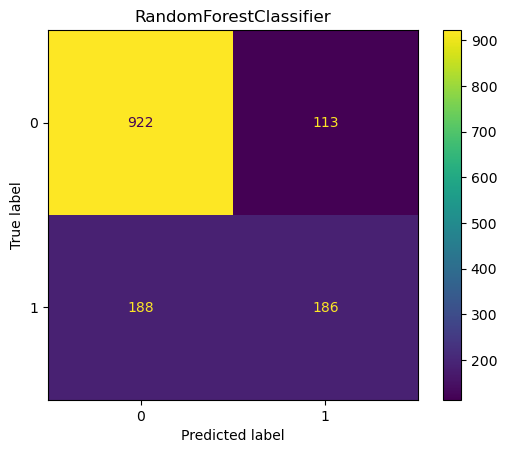

{'0': {'precision': 0.8306306306306306, 'recall': 0.8908212560386474, 'f1-score': 0.8596736596736597, 'support': 1035.0}, '1': {'precision': 0.6220735785953178, 'recall': 0.49732620320855614, 'f1-score': 0.5527488855869243, 'support': 374.0}, 'accuracy': 0.7863733144073811, 'macro avg': {'precision': 0.7263521046129742, 'recall': 0.6940737296236017, 'f1-score': 0.706211272630292, 'support': 1409.0}, 'weighted avg': {'precision': 0.775271980906566, 'recall': 0.7863733144073811, 'f1-score': 0.7782046280849876, 'support': 1409.0}}


In [3]:
baseline_model, report = model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline Random Forest (default parameters, class_weight='balanced') achieves 78.6% overall accuracy, but this figure is misleading given the class imbalance (~73% non-churn / ~27% churn).

For the majority class (non-churners), performance is strong with an F1 of 0.86, which is expected as the model sees more examples of this class.

For the minority class (churners), performance is noticeably weaker — F1 of 0.55. Most critically, recall is only 0.49, meaning the model misses nearly half of all actual churners (false negatives). Since missing a churner is more costly than a false alarm in a business context, this is the key weakness of the baseline.

Despite class_weight='balanced' helping the model account for imbalance, the default hyperparameters are not sufficient to reliably identify churners. This motivates the tuning phase, which will optimise for F1 on class 1 using RandomizedSearchCV.

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}


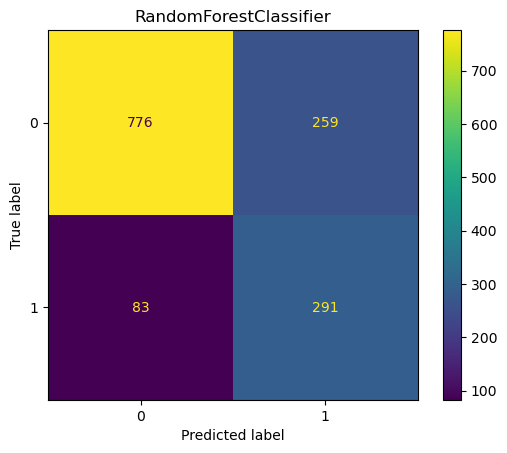

{'0': {'precision': 0.9033760186263097, 'recall': 0.7497584541062802, 'f1-score': 0.8194297782470961, 'support': 1035.0}, '1': {'precision': 0.5290909090909091, 'recall': 0.7780748663101604, 'f1-score': 0.6298701298701299, 'support': 374.0}, 'accuracy': 0.7572746628814763, 'macro avg': {'precision': 0.7162334638586094, 'recall': 0.7639166602082204, 'f1-score': 0.724649954058613, 'support': 1409.0}, 'weighted avg': {'precision': 0.8040270967198229, 'recall': 0.7572746628814763, 'f1-score': 0.7691137324749276, 'support': 1409.0}}


In [4]:
best_model, report = model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned model improves the F1-score for churners from 0.554 → 0.622, driven mainly by a significant recall gain from 0.500 → 0.687 — the model now correctly identifies 69% of churners compared to only 50% in the baseline.

Notably, max_depth=None means trees are allowed to grow fully, unlike what might be expected for a regularised model. The constraint is instead applied through min_samples_leaf=4 and min_samples_split=5, which prevent splits on very small or noisy groups. bootstrap=True is the standard Random Forest behaviour.

Precision drops slightly (0.621 → 0.569), meaning slightly more false alarms — an acceptable trade-off given that missing a churner is the more costly error in this context.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.621 | 0.569 | ↓ |
| Recall (class 1) | 0.500 | 0.687 | ↑↑ |
| F1 (class 1) | 0.554 | 0.622 | ↑ |
| Accuracy | 0.786 | 0.779 | ↓ slightly |

## XGBoost

## Support Vector Machine

In [5]:
from src.models.svm import model_baseline, model_tuning

Support Vector Machine (SVM) is a classification algorithm that finds the optimal hyperplane to separate classes by maximising the margin between them. It is effective in high-dimensional spaces and handles non-linear boundaries well through the use of kernels. For this baseline, a linear kernel is used with class_weight='balanced' to account for class imbalance.

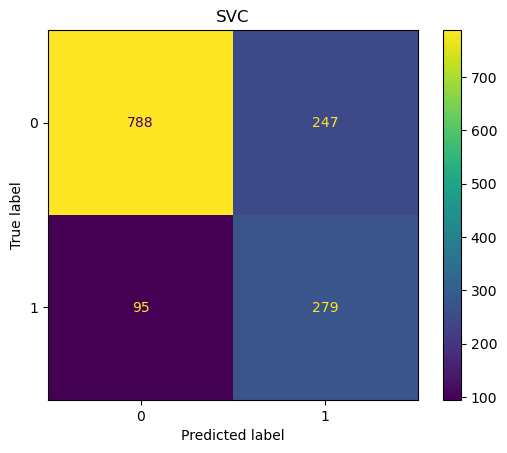

{'0': {'precision': 0.8924122310305775, 'recall': 0.7613526570048309, 'f1-score': 0.821689259645464, 'support': 1035.0}, '1': {'precision': 0.5304182509505704, 'recall': 0.7459893048128342, 'f1-score': 0.62, 'support': 374.0}, 'accuracy': 0.7572746628814763, 'macro avg': {'precision': 0.711415240990574, 'recall': 0.7536709809088326, 'f1-score': 0.720844629822732, 'support': 1409.0}, 'weighted avg': {'precision': 0.7963258232591633, 'recall': 0.7572746628814763, 'f1-score': 0.768153572557172, 'support': 1409.0}}


In [6]:
baseline_model, report = model_baseline(X_train, X_test, y_train, y_test)

print(report)

The SVM baseline with a linear kernel and class_weight='balanced' achieves an F1 of 0.620 for churners — already stronger than the Random Forest baseline (0.553).

The most notable result is the recall of 0.746, meaning the model correctly identifies 75% of actual churners from the start, without any tuning. This comes at the cost of lower precision (0.530), so roughly half the predicted churners are false alarms.

Overall accuracy is 0.757, slightly lower than Random Forest's baseline, but accuracy is less relevant here given the class imbalance — the F1 for churners is the key metric, and SVM starts from a stronger position.

In [ ]:
best_model, report = model_tuning(X_train, X_test, y_train, y_test)

print(report)